In [ ]:
!pip install snowflake-connector-python

In [ ]:
from pyarrow import schema
import snowflake.connector
conn = snowflake.connector.connect(
    user="jeffreysharon5",
    password="Asrufinajeffrey05",
    account="DIMQWDK-NP52406",
    database="DATASET_SAMPLE",
    schema="PUBLIC",
    warehouse="COMPUTE_WH"
)

In [ ]:
query='SELECT * FROM "WATER"'

In [ ]:
import pandas as pd
df=pd.read_sql(query,conn)
conn.close()
df.head()

/tmp/ipykernel_2268/2407966380.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
print(df.isnull().sum())
df.shape

PH                 491
HARDNESS             0
SOLIDS               0
CHLORAMINES          0
SULFATE            781
CONDUCTIVITY         0
ORGANIC_CARBON       0
TRIHALOMETHANES    162
TURBIDITY            0
POTABILITY           0
dtype: int64


(3276, 10)

In [ ]:
df['PH']=df['PH'].fillna(df['PH'].mean())

In [ ]:
df['PH'].isnull().sum()

np.int64(0)

<Axes: ylabel='SULFATE'>

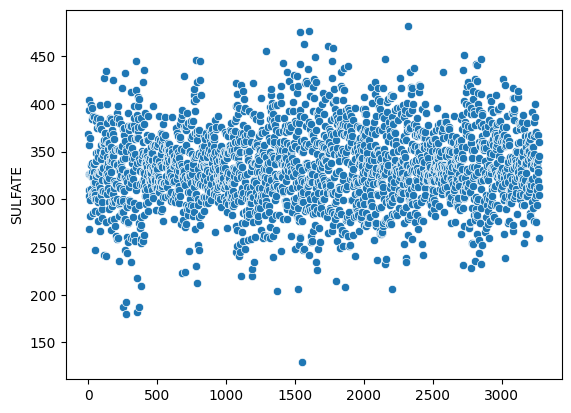

In [ ]:
import seaborn as sns
sns.scatterplot(df['SULFATE'])

In [ ]:
df['SULFATE']=df['SULFATE'].fillna(df['SULFATE'].mean())

<Axes: ylabel='SULFATE'>

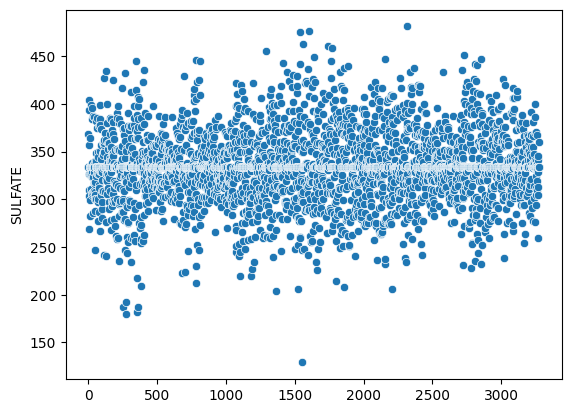

In [ ]:
import seaborn as sns
sns.scatterplot(df['SULFATE'])

<Axes: ylabel='TRIHALOMETHANES'>

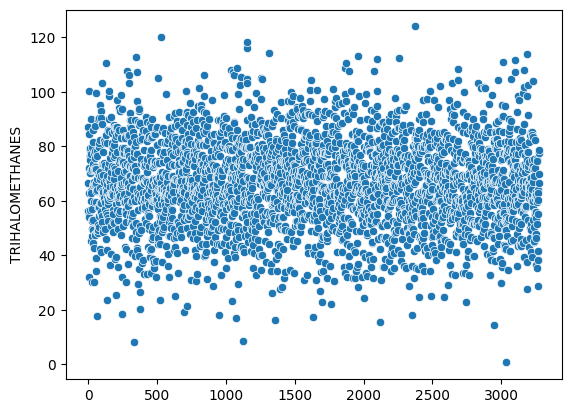

In [ ]:
sns.scatterplot(df['TRIHALOMETHANES'])

In [ ]:
df['TRIHALOMETHANES']=df['TRIHALOMETHANES'].fillna(df['TRIHALOMETHANES'].mean())

In [ ]:
df.isnull().sum()

,0
PH,0
HARDNESS,0
SOLIDS,0
CHLORAMINES,0
SULFATE,0
CONDUCTIVITY,0
ORGANIC_CARBON,0
TRIHALOMETHANES,0
TURBIDITY,0
POTABILITY,0


In [ ]:
out=[]
for colm in df:
  Q1 = df[colm].quantile(0.25)
  Q3 = df[colm].quantile(0.75)
  IQR = Q3 - Q1
  lower_limit = Q1 - 1.5 * IQR
  upper_limit = Q3 + 1.5 * IQR
  outliers = df[(df[colm] < lower_limit)|(df[colm] > upper_limit)]
  out.append([colm,outliers])
  outlierss=pd.DataFrame(out,columns=['columns','out_cnt'])

In [ ]:
print(outlierss)

           columns                                            out_cnt
0               PH               PH    HARDNESS        SOLIDS  CHL...
1         HARDNESS               PH    HARDNESS        SOLIDS  CHL...
2           SOLIDS               PH    HARDNESS        SOLIDS  CHL...
3      CHLORAMINES               PH    HARDNESS        SOLIDS  CHL...
4          SULFATE               PH    HARDNESS        SOLIDS  CHL...
5     CONDUCTIVITY               PH    HARDNESS        SOLIDS  CHL...
6   ORGANIC_CARBON               PH    HARDNESS        SOLIDS  CHL...
7  TRIHALOMETHANES               PH    HARDNESS        SOLIDS  CHL...
8        TURBIDITY              PH    HARDNESS        SOLIDS  CHLO...
9       POTABILITY  Empty DataFrame
Columns: [PH, HARDNESS, SOLIDS...


In [ ]:
import numpy as np
from scipy.stats import zscore
z_score = zscore(df['PH'])
df[np.abs(z_score)>2.5]


,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
9,11.180284,227.231469,25484.508491,9.077200,404.041635,563.885481,17.927806,71.976601,4.370562,0
80,1.844538,233.764343,28689.595778,7.724432,333.775777,410.387264,15.611859,54.299444,5.013463,0
104,2.612036,188.804126,34798.252587,6.796439,333.775777,468.080267,13.170763,49.523770,4.765205,0
113,3.388091,212.028944,20230.125577,8.569782,349.155999,353.912927,18.208340,82.387874,2.798601,0
128,11.180695,228.300860,16600.392747,6.094001,333.775777,504.050539,15.035047,110.739299,3.809842,0
...,...,...,...,...,...,...,...,...,...,...
3094,1.985383,216.480025,23039.328505,6.769268,344.014256,341.078379,11.498237,78.733441,3.923093,0
3107,3.337629,216.257087,42310.827498,8.130663,333.775777,352.264074,14.029673,52.760961,3.300192,0
3108,11.449739,186.652648,12355.344107,7.065576,321.831513,503.964110,16.282371,77.152173,5.166903,0
3249,10.808157,198.596751,29614.348790,5.782418,304.622061,383.269410,14.902820,47.896406,4.362542,1


In [ ]:
import numpy as np
from scipy.stats import zscore
z_score = zscore(df['HARDNESS'])
df[np.abs(z_score)>2.5]

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
18,8.975464,279.357167,19460.398131,6.204321,333.775777,431.443990,12.888759,63.821237,2.436086,0
37,5.618064,304.235912,17281.975168,6.101084,333.775777,399.471566,12.265002,81.588992,2.896547,0
51,7.809632,100.457615,12013.550629,5.212315,247.200826,605.220124,9.611349,66.084174,2.447444,0
67,7.080795,103.464759,27420.167425,8.417305,333.775777,485.974500,11.351133,67.869964,4.620793,0
88,10.155440,300.292476,12652.362979,6.655126,398.647786,487.459131,9.347634,67.919789,5.002467,0
...,...,...,...,...,...,...,...,...,...,...
3186,8.316664,110.903598,24814.485805,9.489566,333.775777,480.472306,14.271247,77.854499,2.695800,1
3217,7.080795,98.367915,28415.575832,10.558950,296.843208,505.240269,12.882614,85.329955,4.119087,1
3218,5.859822,287.975540,3640.734320,4.072626,391.697385,447.121861,6.363175,49.155291,3.426634,1
3221,4.034063,303.702627,33219.074545,4.425559,333.775777,494.320907,13.415230,72.012642,5.024742,1


In [ ]:
import numpy as np
from scipy.stats import zscore
z_score = zscore(df['SOLIDS'])
df[np.abs(z_score)>3]

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
283,10.356119,136.323752,48621.563952,9.158704,327.922751,365.720292,17.975564,77.359854,4.201849,1
366,4.037288,291.461897,52318.917298,7.779459,333.775777,401.204271,16.542921,87.814800,3.045049,1
546,3.410360,207.397473,49074.730407,5.667433,301.975011,351.520393,15.987370,86.639186,3.721766,0
666,7.080795,155.675777,52060.226800,2.577555,365.080963,323.001036,14.166602,48.254307,2.000757,1
1031,5.375896,153.712874,56867.859236,7.894086,333.775777,493.888464,15.116023,57.712992,4.174220,0
1068,3.344589,156.479927,55334.702799,8.530102,371.147770,485.631148,16.980610,69.622490,2.575141,0
1077,8.037430,148.415309,48410.471014,4.755880,268.211896,392.901206,12.466610,66.396293,2.506238,1
1186,9.484703,122.906991,56351.396304,4.219711,219.553437,480.848063,13.533433,41.731219,4.132274,1
1554,8.942046,215.673786,56488.672413,3.231438,129.000000,541.915468,9.313771,70.828374,4.354288,1
1746,7.080795,160.595760,49125.360084,6.344390,409.501953,327.924561,14.407555,64.644993,3.287617,0


In [ ]:
import numpy as np
from scipy.stats import zscore
z_score = zscore(df['CHLORAMINES'])
df[np.abs(z_score)>2.5]

,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
272,6.512737,229.263861,22475.046873,12.580026,192.033592,479.501279,9.983462,66.668576,4.612964,1
275,5.324942,280.089655,35344.658047,13.043806,180.206746,392.421496,10.504820,55.084668,4.427138,1
285,3.882631,243.807950,7751.809491,0.530351,333.775777,341.291116,12.990592,60.109968,3.734001,1
287,10.003301,143.094285,46113.957485,12.912187,333.775777,574.555041,16.963310,36.767671,4.746382,1
304,8.923981,135.938467,27919.770666,12.363285,333.775777,415.629484,11.949914,69.314880,4.155583,1
...,...,...,...,...,...,...,...,...,...,...
2677,7.080795,252.404565,20197.247668,2.562255,350.547757,454.969812,12.031863,69.292252,5.146443,0
2694,3.676845,173.677702,22581.224488,12.653362,289.126846,599.729246,8.386407,49.658554,5.461473,0
2699,3.272820,145.492306,7408.976196,11.996015,336.687809,433.709672,10.458874,66.396293,4.318516,0
2714,6.991685,152.976217,20389.593816,2.648390,331.252916,460.146174,15.485378,69.670038,3.724824,1


In [ ]:
df2=df.copy()
for col in df2:
  lower = df2[col].quantile(0.05)
  upper = df2[col].quantile(0.95)
  df2[col] = df2[col].clip(lower, upper)
df2


,PH,HARDNESS,SOLIDS,CHLORAMINES,SULFATE,CONDUCTIVITY,ORGANIC_CARBON,TRIHALOMETHANES,TURBIDITY,POTABILITY
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,4.688853,141.763281,18630.057858,6.635246,333.775777,566.349320,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,91.744595,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,39.906235,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.688853,193.681735,38474.990249,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,333.775777,392.449580,19.637254,66.396293,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,333.775777,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,333.775777,402.883113,11.168946,77.488213,4.708658,1


<Axes: ylabel='PH'>

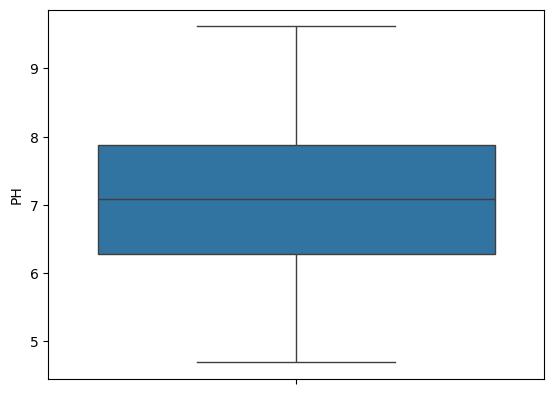

In [ ]:
sns.boxplot(df2['PH'])

<Axes: ylabel='PH'>

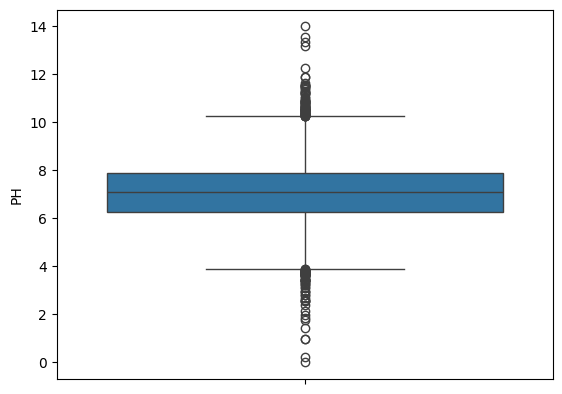

In [ ]:
sns.boxplot(df['PH'])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x = df2.drop("POTABILITY", axis=1)
y = df2['POTABILITY']
scale = StandardScaler()
x_s=scale.fit_transform(x)
x_train,x_test,y_train,y_test=train_test_split(x_s,y,test_size=0.2,random_state=42)
from sklearn.svm import SVC
svc=SVC(kernel='rbf')
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix
print("Accuracy:",accuracy_score(y_pred,y_test))


Accuracy: 0.6844512195121951
